In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
df = pd.read_csv("/Users/athipongjindaphram/Documents/Python For Data Analyst/data_jobs.csv")
#Cleaning Date Column -> Type : Date time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [121]:
df_da_us = df[
    (df["job_title"] == "Data Analyst")
    &
    (df["job_country"] == "United States")
    ].copy()

df_da_us["job_month_no"] = df_da_us["job_posted_date"].dt.month
df_da_us["month_name"] = df_da_us["job_posted_date"].dt.month_name()

In [122]:
df_da_us_explode = df_da_us.explode("job_skills")

In [123]:
df_da_us["job_month_no"] = df_da_us["job_posted_date"].dt.month
df_da_us["month_name"] = df_da_us["job_posted_date"].dt.month_name()

In [124]:
df_da_us_pivot = df_da_us_explode.pivot_table(
    index=["job_month_no", "month_name"],
    values="job_title",
    columns="job_skills",
    aggfunc="size",
    fill_value=0
)
df_da_us_pivot = df_da_us_pivot.reset_index()
df_da_us_pivot = df_da_us_pivot.set_index("month_name")
df_da_us_pivot.loc["total"] = df_da_us_pivot.sum()
df_da_us_pivot = df_da_us_pivot[
    df_da_us_pivot
    .loc["total"]
    .sort_values(ascending=False)
    .index
    ]

df_da_us_pivot = df_da_us_pivot.drop("total")

In [125]:
da_total = df_da_us.groupby("month_name").size()

In [126]:
df_da_us_percent = df_da_us_pivot.div(da_total/100, axis=0).reindex(df_da_us_pivot.index)

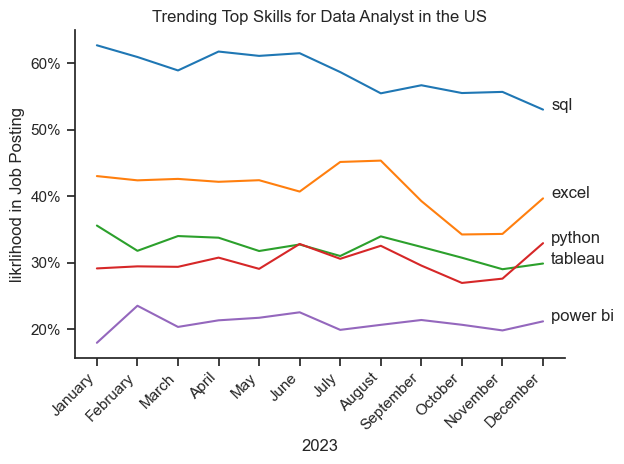

In [127]:
df_plot = df_da_us_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette="tab10")
sns.set_theme(style="ticks")
sns.despine()

plt.title("Trending Top Skills for Data Analyst in the US")
plt.ylabel("likrlihood in Job Posting")
plt.xlabel("2023")
plt.xticks(rotation=45, ha="right")
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])

plt.tight_layout()
plt.show()